In [2]:
from pathlib import Path

search_folder = Path("dog_search_abs")

In [3]:
import pandas as pd
import numpy as np
import pickle
import re


def get_file_index(file_path):
    return list(map(int, re.findall(r'\d+', str(file_path))))

def read_file(file_path):
    with open(file_path, "rb") as f:
        search_dict = pickle.load(f)
    
    return search_dict


In [4]:
# Build the search array results

search_array = np.empty((3, 3, 63), dtype=object)
# Build an array of shape: 3, 3, 63
# of dict with baseline & layers df

for file in search_folder.iterdir():
    # raw_index shape is: layer[1-64], in, out
    raw_index = get_file_index(file)
    # index shape is: in, out, layer[0-63]
    index = raw_index[1], raw_index[2], raw_index[0] - 1
    search_array[index] = read_file(file)

In [5]:
# Check for missing entries
missing_mask = (search_array == None)
if missing_mask.sum() > 0:
    print("Missing files")
    print(np.where(missing_mask))

In [6]:
def select_max_score(entry):
    return entry["search_df"]["score"].max()

In [7]:
best_results_array = np.vectorize(select_max_score)(search_array)

In [8]:
import matplotlib.pyplot as plt

def plot_comp_results(out_comp_select):
    out_comp = ["U", "V", "W"]
    
    plt.title(f"Pearson correlation improvement for {out_comp[out_comp_select]}")
    plt.grid()
    plt.ylabel("Correlation Improvement over baseline")
    plt.xlabel("Y layer")
    
    in_comp = ["Pressure", "Shear_Stress_X", "Shear_Stress_Z"]
    
    for i, in_comp_name in enumerate(in_comp):
        plt.plot(range(1, 64), best_results_array[i, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}")
    plt.legend()
    plt.show()

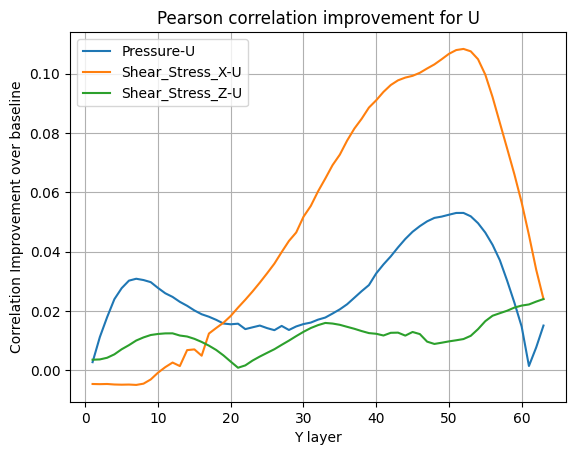

In [9]:
plot_comp_results(0)

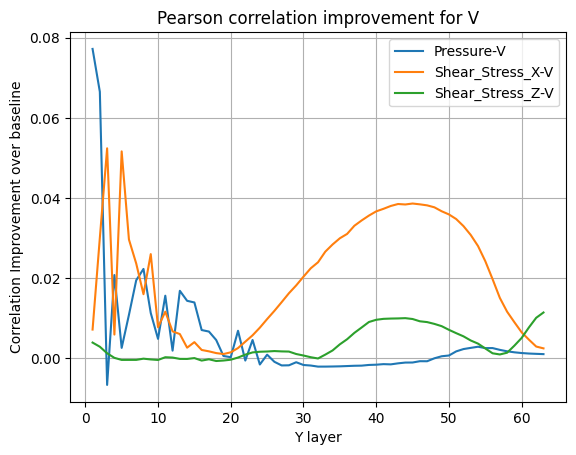

In [10]:
plot_comp_results(1)

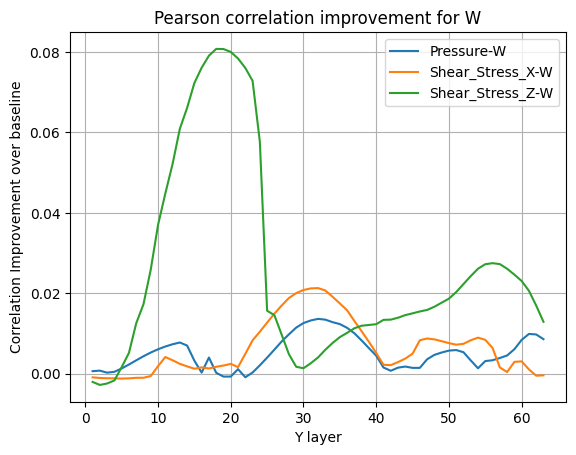

In [11]:
plot_comp_results(2)

In [12]:
def select_real_score(entry):
    return entry["search_df"]["score"].max() + entry["baseline"]

In [13]:
best_correlations_array = np.vectorize(select_real_score)(search_array)

In [14]:
def select_baseline(entry):
    return entry["baseline"]

In [15]:
baseline_array = np.vectorize(select_baseline)(search_array)

In [16]:
import matplotlib.pyplot as plt

def plot_comp_real(out_comp_select):
    out_comp = ["U", "V", "W"]
    
    plt.title(f"Pearson best correlations for {out_comp[out_comp_select]}")
    plt.grid()
    plt.ylabel("Correlation")
    plt.xlabel("Y layer")
    
    in_comp = ["Pressure", "Shear_Stress_X", "Shear_Stress_Z"]
    
    for i, in_comp_name in enumerate(in_comp):
        line, = plt.plot(range(1, 64), best_correlations_array[i, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}")
        plt.plot(range(1, 64), baseline_array[i, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}-baseline", linestyle=":", color=line.get_color())
    plt.legend()
    plt.show()

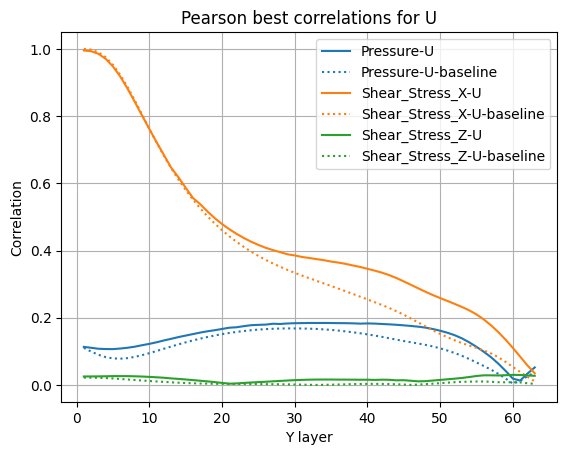

In [17]:
plot_comp_real(0)

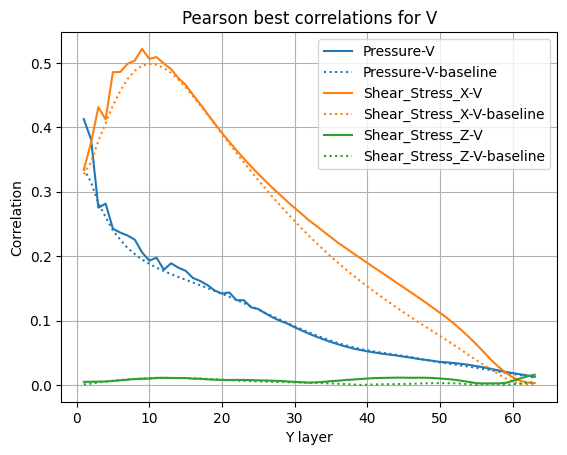

In [18]:
plot_comp_real(1)

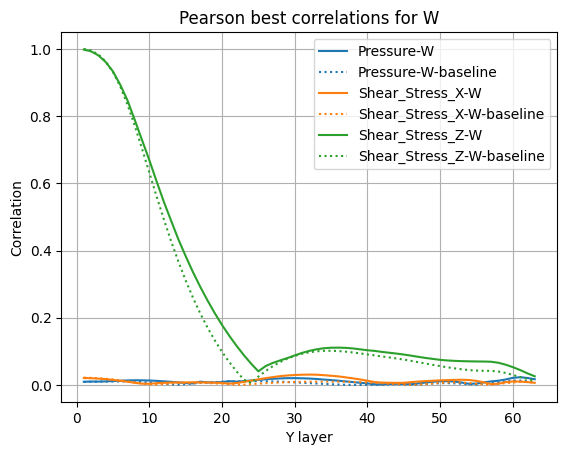

In [19]:
plot_comp_real(2)

In [20]:
def get_sigma_select(sigma):
    def select_sigma(entry):
        best_line_idx = entry["search_df"]["score"].idxmax()
        best_line = entry["search_df"].iloc[best_line_idx]
        return best_line[sigma]
    return select_sigma

In [21]:
best_s1_array = np.vectorize(get_sigma_select("s1"))(search_array)
best_s2_array = np.vectorize(get_sigma_select("s2"))(search_array)

In [22]:

in_comp, out_comp, layer = 0, 0, 61
print(best_s1_array[in_comp, out_comp, layer], best_s2_array[in_comp, out_comp, layer])

28.979737890419532 36.040946065663164


In [23]:
incorrect_mask = best_s2_array - best_s1_array < 0

In [24]:
incorrect_mask.sum()

np.int64(0)

In [25]:
import matplotlib.pyplot as plt

def plot_sigma(in_comp_select, out_comp_select):
    out_comp = ["U", "V", "W"]
        
    in_comp = ["Pressure", "Shear_Stress_X", "Shear_Stress_Z"]
    in_comp_name = in_comp[in_comp_select]
    sigma_range = best_s2_array - best_s1_array
    fig, ax1 = plt.subplots()
    plt.title(f"Best sigmas range for Pearson correlation of {out_comp[out_comp_select]} using {in_comp_name}")
    ax1.set_ylabel("Sigmas")
    ax1.bar(range(1, 64), sigma_range[in_comp_select, out_comp_select], bottom=best_s1_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}")
    ax2 = ax1.twinx()
    color = "tab:red"
    # line, = ax2.plot(range(1, 64), best_correlations_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}", color=color)
    # plt.plot(range(1, 64), baseline_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}-baseline", linestyle=":", color=line.get_color())

    ax2.plot(range(1, 64), best_results_array[in_comp_select, out_comp_select], label=f"Improvement", color=color)
    
    ax2.set_ylabel("Pearson Correlation", color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    plt.legend()
    fig.tight_layout()
    plt.grid()
    plt.xlabel("Y layer")
    plt.show()

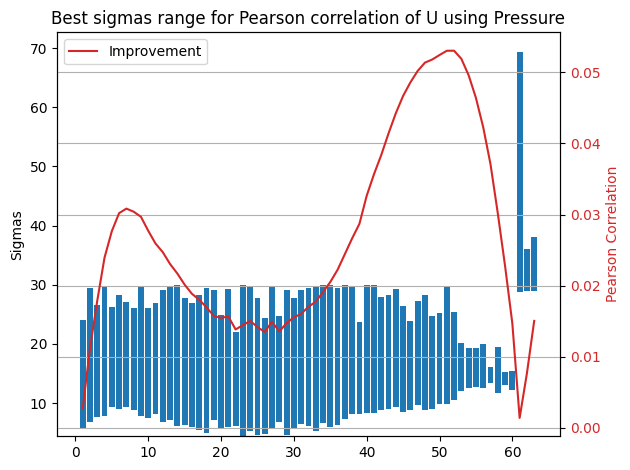

In [26]:
plot_sigma(0, 0)

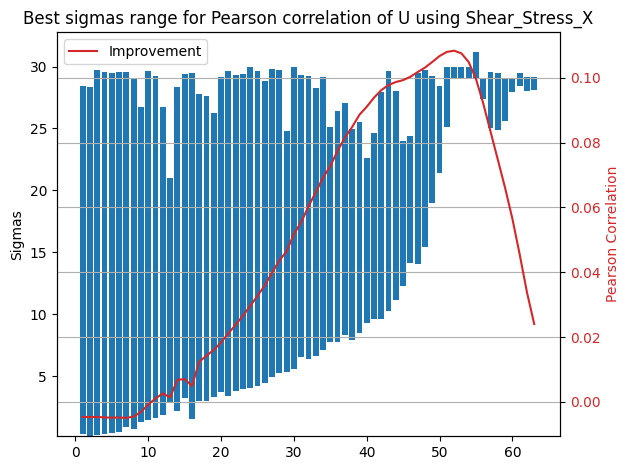

In [27]:
plot_sigma(1, 0)

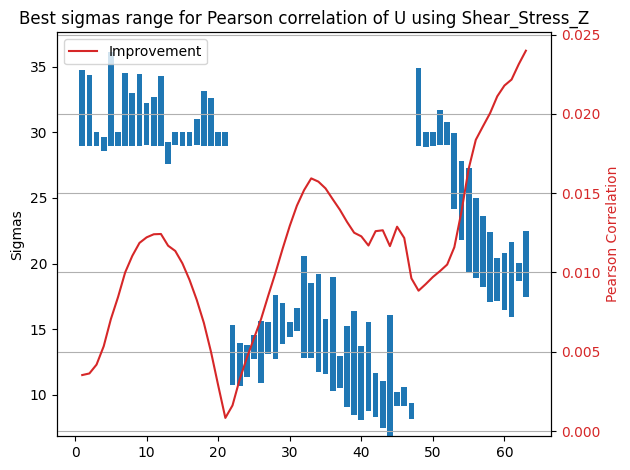

In [28]:
plot_sigma(2, 0)

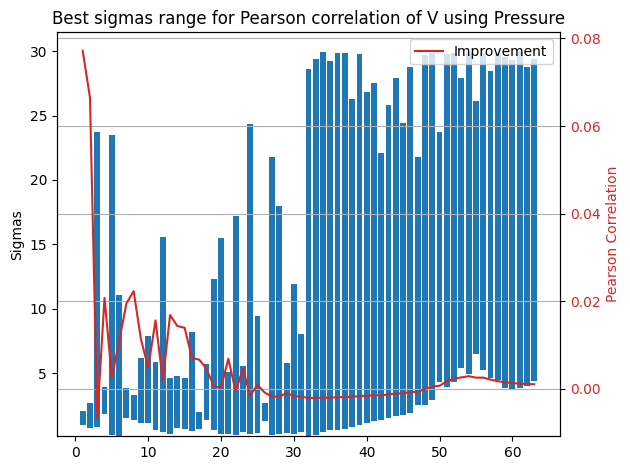

In [29]:
plot_sigma(0, 1)

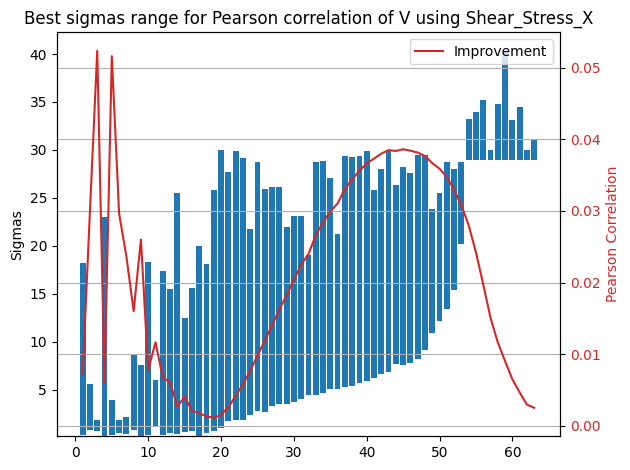

In [30]:
plot_sigma(1, 1)

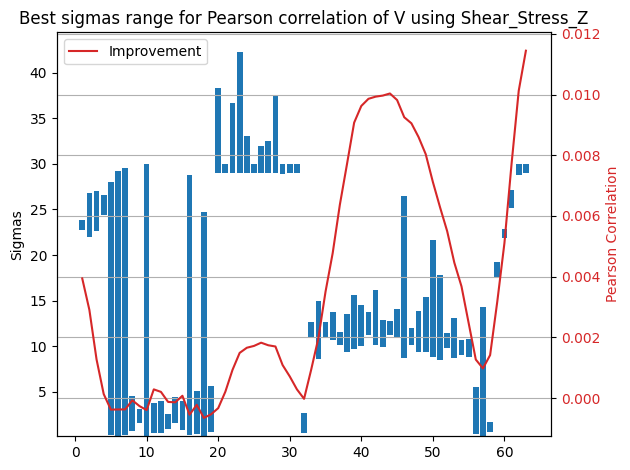

In [31]:
plot_sigma(2, 1)

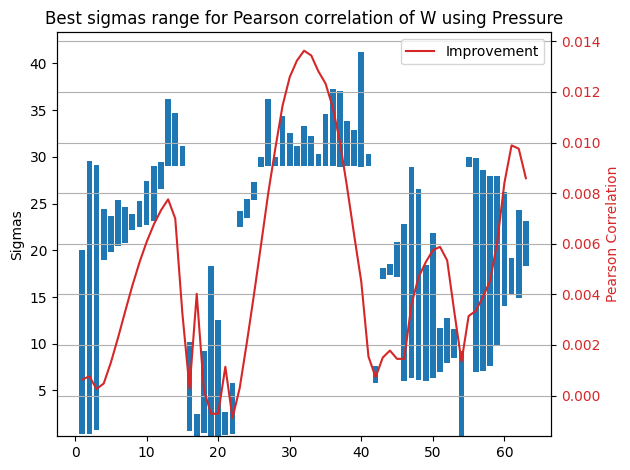

In [32]:
plot_sigma(0, 2)

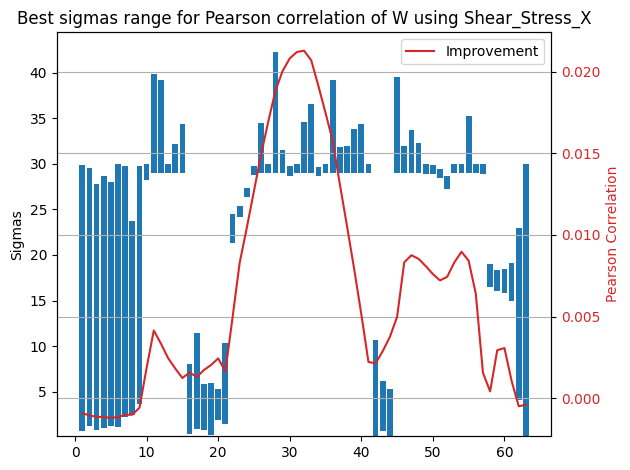

In [33]:
plot_sigma(1, 2)

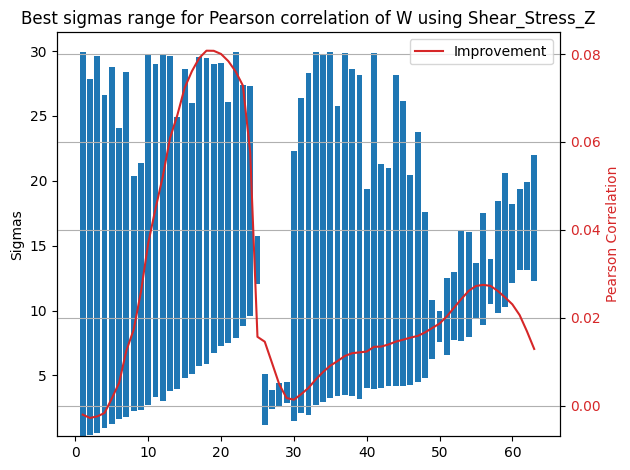

In [34]:
plot_sigma(2, 2)

In [35]:
# This is like grocery shopping, just put any index you like, then we fetch the sigmas for all,
# and we see which sigmas we can "merge", which will reduce the amount of inputs
# So don't be afraid of being greedy, but be careful that not all indices are equals!
# Some have greater correlations and should be prioritized

improvement_indices = [
    [
        [10, 45, 55, 63],  # Pressure
        [25, 35, 45, 50, 60],  # Shear Stress X
        [10, 35, 60],  # Shear Stress Z
    ],
    [
        [1, 4],  # Pressure
        [2, 40, 50],  # Shear Stress X
        [40, 63],  # Shear Stress Z
    ],
    [
        [15, 35, 50, 60],  # Pressure
        [30, 33],  # Shear Stress X
        [17, 55],  # Shear Stress Z
    ],
]

# fetch the sigmas
sigmas = []

for out_comp_i, out_components in enumerate(improvement_indices):
    sigmas.append([])
    for in_comp_i, in_components in enumerate(out_components):
        sigmas[out_comp_i].append([])
        for layer_i, layer in enumerate(in_components):
            
            s1 = best_s1_array[in_comp, out_comp, layer - 1]
            s2 = best_s2_array[in_comp, out_comp, layer - 1]
            weight = best_results_array[in_comp, out_comp, layer - 1]

            sigmas[out_comp_i][in_comp_i].append((s1, s2, weight)) 
        


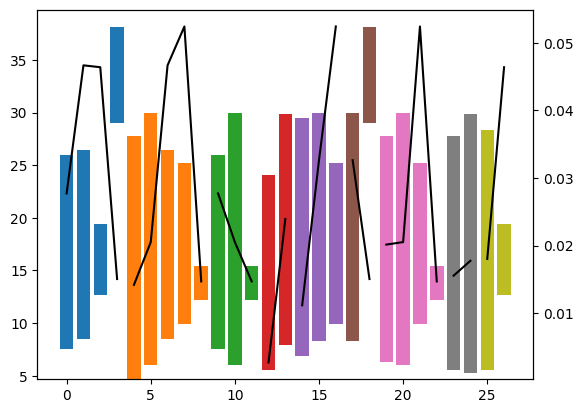

In [36]:
tot_cmp = 0
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
out_labels = ["U", "V", "W"]
in_labels = ["Pressure", "Shear Stress X", "Shear Stress Z"]

for out_comp_i, out_components in enumerate(sigmas):
    for in_comp_i, in_components in enumerate(out_components):
        ranges = [s2 - s1 for s1, s2, w in in_components]
        bot = [s1 for s1, s2, w in in_components]
        weights = [w for s1, s2, w in in_components]
        r = list(range(tot_cmp, tot_cmp + len(ranges)))
        
        ax1.bar(r, ranges, bottom=bot, label=f"{in_labels[in_comp_i]}-{out_labels[out_comp_i]}")
        
        ax2.plot(r, weights, color="black")
        tot_cmp += len(ranges)

# ax1.legend()
plt.show()
            

In [37]:
flat_sigmas = [(s1, s2, w) for out_components in sigmas for in_components in out_components for s1, s2, w in in_components]

In [38]:
s1s = [s1 for s1, s2, w in flat_sigmas]
s2s = [s2 for s1, s2, w in flat_sigmas]
weights = np.array([w for s1, s2, w in flat_sigmas])

Text(0, 0.5, 's2')

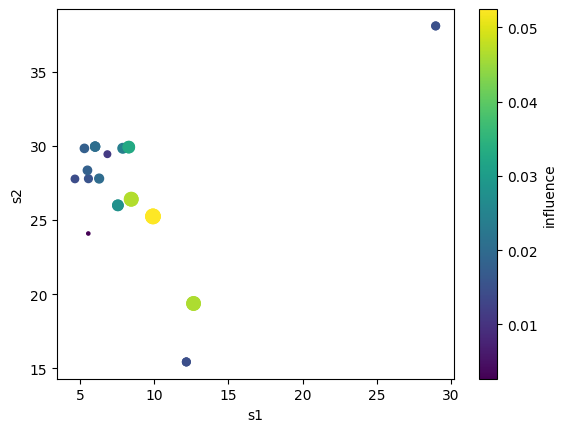

In [39]:
fig, ax = plt.subplots(nrows=1, ncols=1) 
p = plt.scatter(s1s, s2s, s=weights * 2000, c=weights)
plt.colorbar(p, ax=ax,orientation='vertical',label='influence')
plt.xlabel("s1")
plt.ylabel("s2")

In [41]:
from sklearn.cluster import KMeans

X = [(s1, s2) for s1, s2, w in flat_sigmas]

kmeans = KMeans(n_clusters=7, n_init=10, random_state=0, max_iter=1000)
wt_kmeansclus = kmeans.fit(X, sample_weight = weights)
predicted_kmeans = kmeans.predict(X)



In [42]:
predicted_kmeans

array([6, 6, 3, 2, 5, 5, 6, 1, 4, 6, 5, 4, 6, 0, 5, 0, 1, 0, 2, 5, 5, 1,
       4, 5, 5, 5, 3], dtype=int32)

In [43]:
kmeans.cluster_centers_

array([[ 8.18623679, 29.89783716],
       [ 9.92413246, 25.24348738],
       [28.96406365, 38.09521249],
       [12.65697882, 19.36854765],
       [12.17130377, 15.42589306],
       [ 5.81449573, 29.03987864],
       [ 8.07956629, 26.2110599 ]])

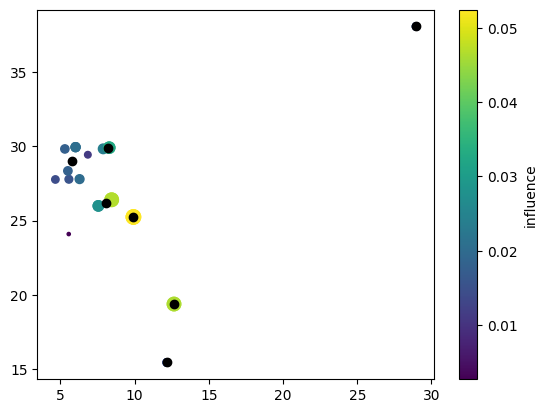

In [44]:
fig, ax = plt.subplots(nrows=1, ncols=1) 
p = plt.scatter(s1s, s2s, s=weights * 2000, c=weights)
plt.colorbar(p, ax=ax,orientation='vertical',label='influence')
plt.scatter([x for x,y in kmeans.cluster_centers_], [y for x,y in kmeans.cluster_centers_], color="black")

# Validate data now

In [45]:
import numpy as np
from space_exploration.beans.dataset_bean import Dataset
from space_exploration.dataset.transforms.AllTransforms import TransformationReferences
dataset_name = "re200-sr1etot"
dataset = Dataset.get_dataset_or_fail(dataset_name)
# ds = dataset.get_training_dataset(64, TransformationReferences.DEFAULT_UNCHANGED.transformation, TransformationReferences.DEFAULT_UNCHANGED.transformation, size=1000)
ds = dataset.get_training_dataset(64, TransformationReferences.COMPONENT_NORMALIZE.transformation, TransformationReferences.Y_ALONG_COMPONENT_NORMALIZE.transformation, size=1000)
xs = np.array([x.numpy() for x, y in ds])
ys = np.array([y.numpy() for x, y in ds])

Loading std & mean of dataset re200-sr1etot
Loading stds & means of dataset re200-sr1etot
⌛ Initializing Dataset...
X...
[########################################] | 100% Completed | 666.96 ms
Y...
[########################################] | 100% Completed | 10.24 s


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn.functional as F
from scipy.stats import pearsonr

def get_gaussian_kernel2d(kernel_size=5, sigma=1.0, device='cpu'):
    coords = torch.arange(kernel_size, dtype=torch.float32, device=device) - kernel_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g /= g.sum()
    g2d = g[:, None] * g[None, :]  # outer product for 2D kernel
    g2d = g2d.unsqueeze(0).unsqueeze(0)  # shape (1,1,k,k)
    return g2d

def apply_dog_2d(images, sigma1=1.0, sigma2=2.0, kernel_size=9):
    """
    ys: torch.Tensor of shape (B, C, H, W)
    returns: DoG-filtered tensor, same shape
    """
    B, C, H, W = images.shape
    device = images.device
    
    # Get both Gaussian kernels
    g1 = get_gaussian_kernel2d(kernel_size, sigma1, device=device)
    g2 = get_gaussian_kernel2d(kernel_size, sigma2, device=device)
    
    # Depthwise convolution for both sigmas
    blurred1 = F.conv2d(images, g1, padding="same")
    blurred2 = F.conv2d(images, g2, padding="same")

    # Difference of Gaussians
    return blurred1 - blurred2

def get_correlation(x, y, s1, s2):
        # x: B, 1, 64, 64
        # y : B, 1, 64, 64
        x = torch.tensor(x, device="cuda")
        dog = apply_dog_2d(x, sigma1=s1, sigma2=s2, kernel_size=63).cpu()
        correlations = [pearsonr(dog[i].ravel(), y[i].ravel())[0] for i in range(dog.shape[0])]
        return abs(np.mean(correlations))

In [53]:
tested_sigmas = kmeans.cluster_centers_

In [188]:
import random

correlations = np.zeros((3, 3, len(tested_sigmas), 63))

from tqdm import trange
for layer in trange(1, 63):
    for in_comp in range(3):
        for out_comp in range(3):
            for i, (s1, s2) in enumerate(tested_sigmas):
            
                correlations[in_comp, out_comp, i, layer - 1] = get_correlation(xs[:, in_comp:in_comp+1, :, 0, :], ys[:, out_comp:out_comp+1, :, layer, :], s1, s2)
        



100%|███████████████████████████████████████████| 62/62 [14:43<00:00, 14.25s/it]


In [189]:
with open('correlations_abs.npy', 'wb') as f:
    np.save(f, correlations)

In [48]:
correlations = np.load('correlations_abs.npy')

In [54]:
tested_sigmas[correlations.argmax((2))].shape

(3, 3, 63, 2)

In [55]:
correlations.shape

(3, 3, 7, 63)

In [56]:
import matplotlib.pyplot as plt

def plot_best_sigma(in_comp_select, out_comp_select):
    out_comp = ["U", "V", "W"]
        
    in_comp = ["Pressure", "Shear_Stress_X", "Shear_Stress_Z"]
    in_comp_name = in_comp[in_comp_select]

    best_corr = correlations.max((2))
    used_sigmas = tested_sigmas[correlations.argmax((2))]

    best_s1_array = used_sigmas[:, :, :, 0]
    best_s2_array = used_sigmas[:, :, :, 1]
    
    sigma_range = best_s2_array - best_s1_array
    fig, ax1 = plt.subplots()
    plt.title(f"Best sigmas range for Pearson correlation of {out_comp[out_comp_select]} using {in_comp_name}")
    ax1.set_ylabel("Sigmas")
    ax1.bar(range(1, 64), sigma_range[in_comp_select, out_comp_select], bottom=best_s1_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}")
    ax2 = ax1.twinx()
    color = "tab:red"
    # line, = ax2.plot(range(1, 64), best_correlations_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}", color=color)
    # plt.plot(range(1, 64), baseline_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}-baseline", linestyle=":", color=line.get_color())

    ax2.plot(range(1, 64), best_corr[in_comp_select, out_comp_select], label=f"Best correlations of reduced set", color=color)
    plt.plot(range(1, 64), best_correlations_array[in_comp_select, out_comp_select], label=f"Best correlations found", color=color, linestyle=":")
    
    ax2.set_ylabel("Pearson Correlation", color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    plt.legend()
    fig.tight_layout()
    plt.grid()
    plt.xlabel("Y layer")
    plt.show()

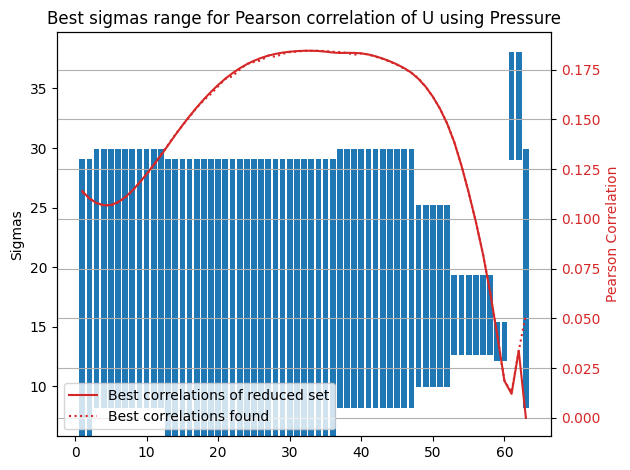

In [57]:
plot_best_sigma(0, 0)

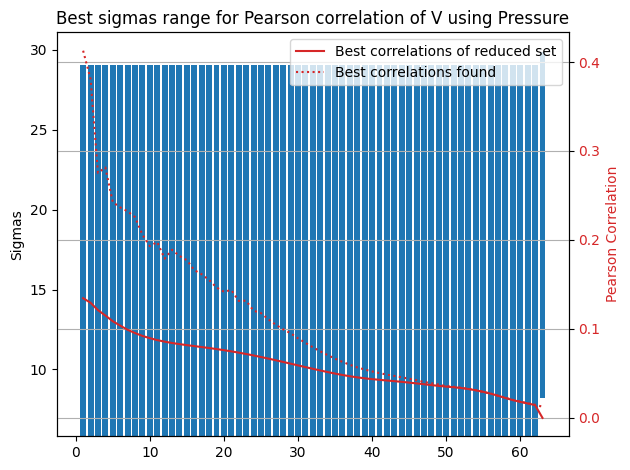

In [58]:
plot_best_sigma(0, 1)

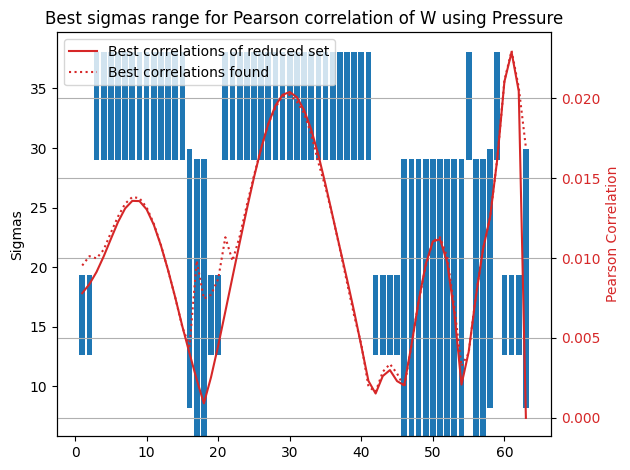

In [59]:
plot_best_sigma(0, 2)

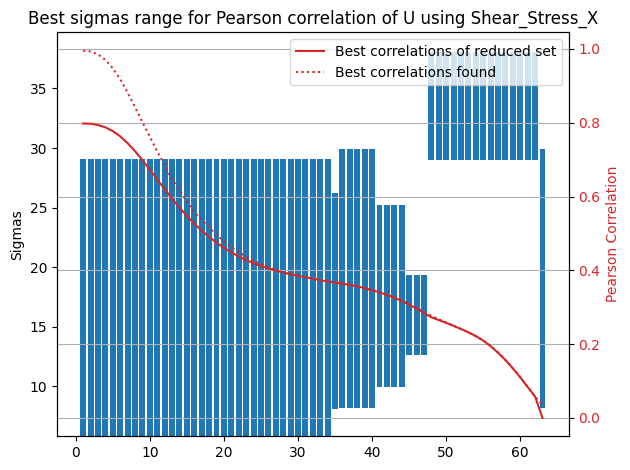

In [60]:
plot_best_sigma(1, 0)

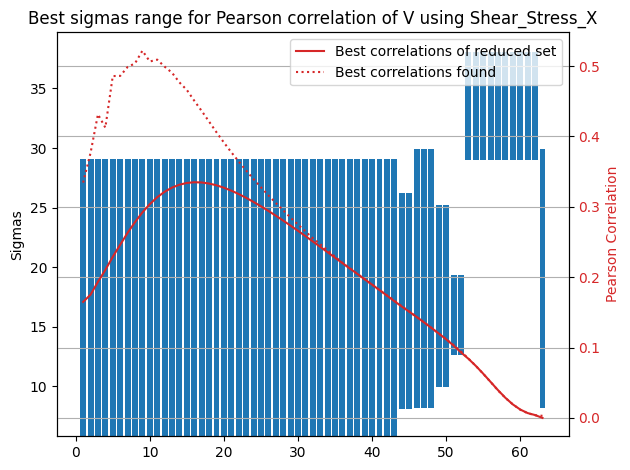

In [61]:
plot_best_sigma(1, 1)

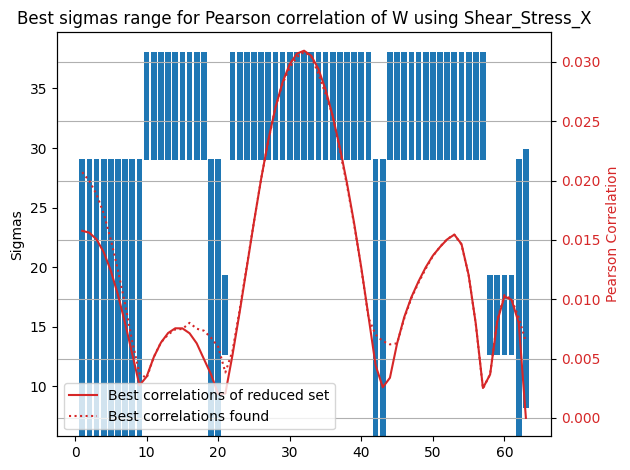

In [62]:
plot_best_sigma(1, 2)

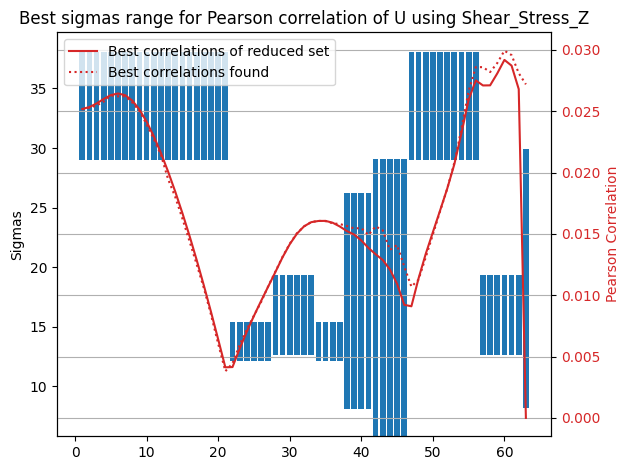

In [63]:
plot_best_sigma(2, 0)

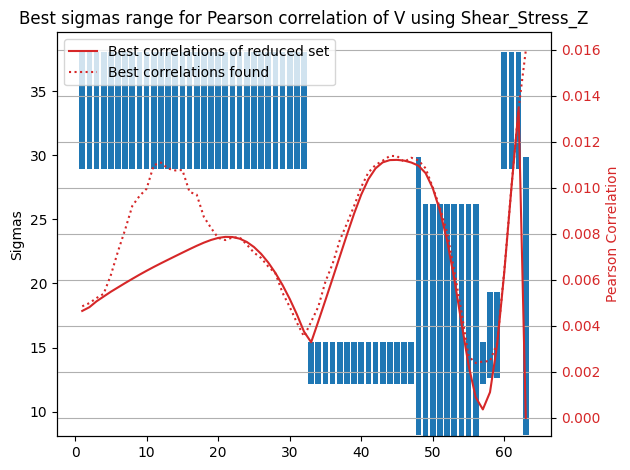

In [64]:
plot_best_sigma(2, 1)

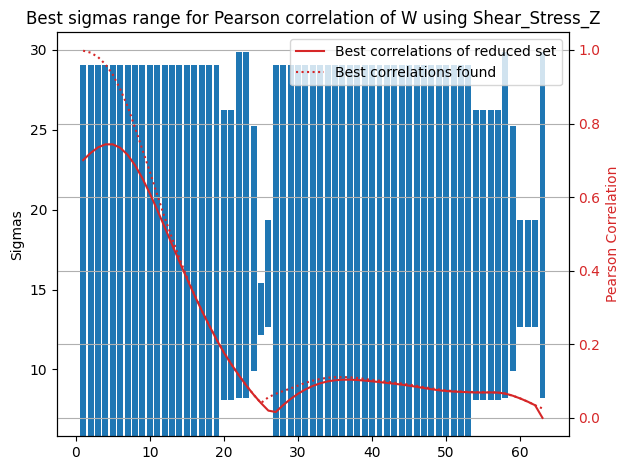

In [65]:
plot_best_sigma(2, 2)

In [214]:
original_correlation = np.zeros((3, 3, 63))
for layer in trange(1, 64):
    for in_comp in range(3):
        for out_comp in range(3):
            s1 = best_s1_array[in_comp, out_comp, layer - 1]
            s2 = best_s2_array[in_comp, out_comp, layer - 1]
            original_correlation[in_comp, out_comp, layer - 1] =  get_correlation(xs[:, in_comp:in_comp+1, :, 0, :], ys[:, out_comp:out_comp+1, :, layer, :], s1, s2)


  2%|▋                                           | 1/63 [00:03<03:06,  3.01s/it]


KeyboardInterrupt: 

In [201]:
np.mean((original_correlation - best_correlations_array) ** 2)

np.float64(3.346994506984097e-20)

In [198]:
import matplotlib.pyplot as plt


def test_previous_sigmas(in_comp_select, out_comp_select):
    out_comp = ["U", "V", "W"]
        
    in_comp = ["Pressure", "Shear_Stress_X", "Shear_Stress_Z"]
    in_comp_name = in_comp[in_comp_select]

    sigma_range = best_s2_array - best_s1_array
    fig, ax1 = plt.subplots()
    plt.title(f"Best sigmas range for Pearson correlation of {out_comp[out_comp_select]} using {in_comp_name}")
    ax1.set_ylabel("Sigmas")
    ax1.bar(range(1, 64), sigma_range[in_comp_select, out_comp_select], bottom=best_s1_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}")
    ax2 = ax1.twinx()
    color = "tab:red"
    line, = ax2.plot(range(1, 64), best_correlations_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}", color=color)
    plt.plot(range(1, 64), original_correlation[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}-baseline", linestyle=":", color=line.get_color())

    
    ax2.set_ylabel("Pearson Correlation", color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    plt.legend()
    fig.tight_layout()
    plt.grid()
    plt.xlabel("Y layer")
    plt.show()

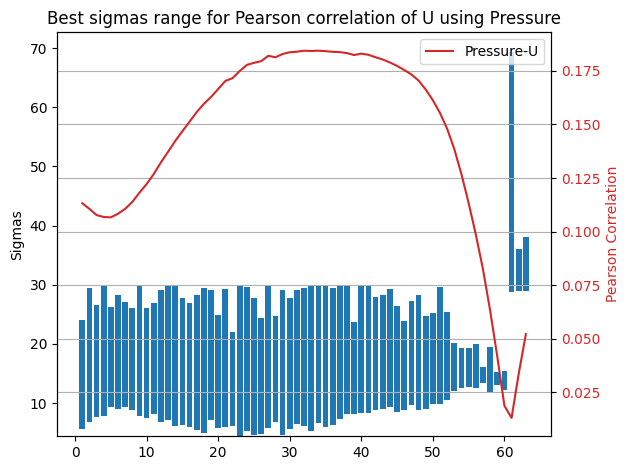

In [199]:
test_previous_sigmas(0, 0)